In [1]:
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, median_absolute_error, root_mean_squared_error
from scipy.stats import spearmanr

from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
try:
    from skrvm import RVR
except ImportError:
    print("skrvm yüklü değil, RVM atlanacak.")

from ngboost import NGBRegressor
from ngboost.distns import Normal

import torch
import torch.nn as nn
from pytorch_tabular import TabularModel
from pytorch_tabular.models import NodeConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig

from contextlib import contextmanager
import sys

@contextmanager
def suppress_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import KFold
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error

p = 1.543
power = 2 - p

def forward_transform(y):
    return np.power(y, power) / power

def inverse_transform(y):
    return np.power(np.maximum(y, 0) * power, 1/power)

X_train = pd.read_csv("../../data/processed/X_train_v2.csv") 
X_test = pd.read_csv("../../data/processed/X_test_v2.csv") 
y_train_raw = pd.read_csv("../../data/processed/y_train_v2.csv").squeeze().values 
y_test_v2 = pd.read_csv("../../data/processed/y_test_v2.csv").squeeze().values

y_train_tweedie = forward_transform(y_train_raw)

results_df = pd.DataFrame(columns=[
    'Architecture', 'Data_Type', 'Model', 
    'MedAE', 'MAE', 'MAD', 'RMSE', 'Spearman', 
    'Zero_HA_Acc', 'Coverage_90%', 'Avg_Interval_Width'
])

print(f"Eğitim Verisi RAW Max: {y_train_raw.max():.2f}")
print(f"Eğitim Verisi Optimum Tweedie Max: {y_train_tweedie.max():.2f}")
print(f"Test Verisi RAW Max: {y_test_v2.max():.2f}")

Eğitim Verisi RAW Max: 746.28
Eğitim Verisi Optimum Tweedie Max: 44.98
Test Verisi RAW Max: 1090.84


In [ ]:
def evaluate_and_append(architecture_name, data_type, model_name, y_true_raw, y_pred_raw, coverage, avg_width):
    global results_df
    y_pred_safe = np.maximum(y_pred_raw, 0)
    
    medae = median_absolute_error(y_true_raw, y_pred_safe)
    mae = mean_absolute_error(y_true_raw, y_pred_safe)
    mad = np.median(np.abs(y_pred_safe - np.median(y_pred_safe)))
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_safe))
    
    spearman_corr, _ = stats.spearmanr(y_true_raw, y_pred_safe)
    spearman_corr = 0.0 if np.isnan(spearman_corr) else spearman_corr
        
    zero_mask = (y_true_raw == 0)
    zero_ha_acc = np.mean(y_pred_safe[zero_mask] <= 0.5) * 100 if np.sum(zero_mask) > 0 else 0.0
        
    new_row = {
        'Architecture': architecture_name, 'Data_Type': data_type, 'Model': model_name,
        'MedAE': round(medae, 4), 'MAE': round(mae, 4), 'MAD': round(mad, 4), 'RMSE': round(rmse, 4),
        'Spearman': round(spearman_corr, 4), 'Zero_HA_Acc': round(zero_ha_acc, 2),
        'Coverage_90%': round(coverage, 2), 'Avg_Interval_Width': round(avg_width, 2)
    }
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

def conformal_cv(model, X, y_target, y_true_raw, is_tweedie, alpha=0.10):
    oof_preds_raw = np.zeros(len(X))
    coverage_flags = np.zeros(len(X))
    interval_widths = np.zeros(len(X))
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_target[train_idx], y_target[val_idx]
        
        with suppress_output():
            model.fit(X_tr, y_tr)
            preds_val = model.predict(X_val)
            preds_tr = model.predict(X_tr)
        
        if is_tweedie:
            preds_val_raw = inverse_transform(preds_val)
            preds_tr_raw = inverse_transform(preds_tr)
        else:
            preds_val_raw = np.maximum(preds_val, 0)
            preds_tr_raw = np.maximum(preds_tr, 0)
            
        y_tr_raw = y_true_raw[train_idx]
        residuals_tr_raw = np.abs(y_tr_raw - preds_tr_raw)
        margin_raw = np.quantile(residuals_tr_raw, 1 - alpha)
        
        lower_raw = np.maximum(preds_val_raw - margin_raw, 0)
        upper_raw = preds_val_raw + margin_raw
            
        oof_preds_raw[val_idx] = preds_val_raw
        interval_widths[val_idx] = upper_raw - lower_raw
        
        y_true_val = y_true_raw[val_idx]
        coverage_flags[val_idx] = (y_true_val >= lower_raw) & (y_true_val <= upper_raw)
        
    return oof_preds_raw, np.mean(coverage_flags) * 100, np.mean(interval_widths)


In [4]:
import logging
import os
import sys
import pandas as pd
from contextlib import contextmanager
from sklearn.base import BaseEstimator, RegressorMixin
from pytorch_tabular import TabularModel
from pytorch_tabular.models import NodeConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

@contextmanager
def suppress_output():
    logger = logging.getLogger("pytorch_tabular")
    pl_logger = logging.getLogger("lightning.pytorch")
    
    old_level = logger.level
    pl_old_level = pl_logger.level
    
    logger.setLevel(logging.WARNING)
    pl_logger.setLevel(logging.WARNING)
    
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr
            logger.setLevel(old_level)
            pl_logger.setLevel(pl_old_level)

class SklearnNODE(BaseEstimator, RegressorMixin):
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.model = None
        self._is_first_fit = True

    def fit(self, X, y):
        train_df = pd.DataFrame(X).copy()
        train_df.columns = [f"col_{i}" for i in range(train_df.shape[1])]
        train_df['target'] = y
        
        data_config = DataConfig(target=['target'], continuous_cols=list(train_df.columns[:-1]), categorical_cols=[])
        
        trainer_config = TrainerConfig(
            batch_size=32, 
            max_epochs=20, 
            early_stopping=None, 
            progress_bar="none",
            trainer_kwargs={"enable_model_summary": False}
        )
        
        optimizer_config = OptimizerConfig()
        model_config = NodeConfig(task="regression", num_layers=2, num_trees=1024, depth=4, metrics=["mean_squared_error"])
        
        self.model = TabularModel(
            data_config=data_config, model_config=model_config, 
            optimizer_config=optimizer_config, trainer_config=trainer_config, 
            verbose=False, suppress_lightning_logger=True
        )
        
        with suppress_output():
            self.model.fit(train_df)
            
        if self._is_first_fit:
            print("  -> [NODE] Kurulum Başarılı (17.1M Parametre).")
            self._is_first_fit = False
            
        return self

    def predict(self, X):
        test_df = pd.DataFrame(X).copy()
        test_df.columns = [f"col_{i}" for i in range(test_df.shape[1])]
        with suppress_output():
            preds_df = self.model.predict(test_df)
        pred_col = [col for col in preds_df.columns if 'prediction' in col.lower()][0]
        return preds_df[pred_col].values
        

## BASELİNE MODEL Testi:

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.metrics import median_absolute_error, mean_absolute_error, mean_squared_error
from IPython.display import display

if 'X_test' not in globals():
    X_test = pd.read_csv("../../data/processed/X_test_v2.csv")

baseline_node_cv = SklearnNODE(random_state=42)

oof_preds_raw, cov_cv, width_cv = conformal_cv(
    model=baseline_node_cv, 
    X=X_train, 
    y_target=y_train_tweedie, 
    y_true_raw=y_train_raw, 
    is_tweedie=True, 
    alpha=0.1
)

evaluate_and_append(
    architecture_name='Baseline (Eğitim CV)',
    data_type='Tweedie',
    model_name='Sadece NODE',
    y_true_raw=y_train_raw,
    y_pred_raw=oof_preds_raw,
    coverage=cov_cv,
    avg_width=width_cv
)

baseline_node_test = SklearnNODE(random_state=42)
baseline_node_test.fit(X_train, y_train_tweedie)

preds_tr_base = baseline_node_test.predict(X_train)
residuals_tr_base = np.abs(y_train_tweedie - preds_tr_base)
margin_base = np.quantile(residuals_tr_base, 0.90) 

preds_te_base = baseline_node_test.predict(X_test)
lower_base = np.maximum(np.expm1(preds_te_base - margin_base), 0)
upper_base = np.maximum(np.expm1(preds_te_base + margin_base), 0)
preds_raw_base = np.maximum(np.expm1(preds_te_base), 0)

base_cov = np.mean((y_test_v2 >= lower_base) & (y_test_v2 <= upper_base)) * 100
base_width = np.mean(upper_base - lower_base)

evaluate_and_append(
    architecture_name='Baseline (Test Seti)',
    data_type='Tweedie',
    model_name='Sadece NODE',
    y_true_raw=y_test_v2,
    y_pred_raw=preds_raw_base,
    coverage=base_cov,
    avg_width=base_width
)

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

2026-07-29 14:23:02,007 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 14:27:47,937 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 14:31:55,920 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 14:36:01,406 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 14:40:00,266 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 14:44:41,768 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).


,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Baseline (Eğitim CV),Tweedie,Sadece NODE,0.24,11.06,0.00,46.98,-0.04,100.00,89.83,23.70
1,Baseline (Test Seti),Tweedie,Sadece NODE,1.99,19.98,0.05,109.84,0.21,0.00,100.00,12379.02


## HURDLE Testi:

In [8]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from ngboost import NGBRegressor
try:
    from skrvm import RVR
except ImportError:
    pass

if 'X_test' not in globals():
    X_test = pd.read_csv("../../data/processed/X_test_v2.csv")

y_class = (y_train_raw > 0).astype(int)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_class)

pos_mask = (y_train_raw > 0)
X_train_pos, y_train_pos = X_train[pos_mask], y_train_tweedie[pos_mask]
y_train_raw_pos = y_train_raw[pos_mask]

trained_regressors = {
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train_pos, y_train_pos),
    'NGBoost': NGBRegressor(random_state=42, verbose=False).fit(X_train_pos, y_train_pos),
    'NODE': SklearnNODE(random_state=42).fit(X_train_pos, y_train_pos)
}
if 'RVR' in globals():
    trained_regressors['RVM'] = RVR(kernel='rbf').fit(X_train_pos, y_train_pos)

for reg_name, trained_reg in trained_regressors.items():
    preds_tr_pos = trained_reg.predict(X_train_pos)
    preds_tr_raw_pos = inverse_transform(preds_tr_pos)
    residuals_raw = np.abs(y_train_raw_pos - preds_tr_raw_pos)
    margin_raw = np.quantile(residuals_raw, 0.90)
    
    test_class_preds = rf_classifier.predict(X_test)
    test_pos_mask = (test_class_preds == 1)
    
    final_preds_raw = np.zeros(len(X_test))
    lower_raw = np.zeros(len(X_test))
    upper_raw = np.zeros(len(X_test))
    
    if test_pos_mask.sum() > 0:
        itfaiye_preds_tweedie = trained_reg.predict(X_test[test_pos_mask])
        itfaiye_preds_raw = inverse_transform(itfaiye_preds_tweedie)
        
        final_preds_raw[test_pos_mask] = itfaiye_preds_raw
        lower_raw[test_pos_mask] = np.maximum(itfaiye_preds_raw - margin_raw, 0)
        upper_raw[test_pos_mask] = itfaiye_preds_raw + margin_raw
        
    cov = np.mean((y_test_v2 >= lower_raw) & (y_test_v2 <= upper_raw)) * 100
    width = np.mean(upper_raw - lower_raw)
    
    evaluate_and_append(
        architecture_name='Hurdle (Test Seti)',
        data_type='Tweedie (p=1.543)',
        model_name=f'RF + {reg_name}',
        y_true_raw=y_test_v2,
        y_pred_raw=final_preds_raw,
        coverage=cov,
        avg_width=width
    )

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

2026-07-29 14:59:10,905 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).


,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Baseline (Eğitim CV),Tweedie,Sadece NODE,0.24,11.06,0.00,46.98,-0.04,100.00,89.83,23.70
1,Baseline (Test Seti),Tweedie,Sadece NODE,1.99,19.98,0.05,109.84,0.21,0.00,100.00,12379.02
2,Hurdle (Test Seti),Tweedie (p=1.543),RF + XGBoost,3.14,21.39,0.00,110.12,0.28,69.39,32.69,0.01
3,Hurdle (Test Seti),Tweedie (p=1.543),RF + NGBoost,3.32,20.54,0.00,109.88,0.26,69.39,73.08,13.70
4,Hurdle (Test Seti),Tweedie (p=1.543),RF + NODE,0.65,19.88,0.00,110.18,0.28,100.00,74.04,18.38
5,Hurdle (Test Seti),Tweedie (p=1.543),RF + RVM,2.40,19.85,0.00,109.97,0.27,69.39,45.19,2.24


## STACKING Testi:

In [13]:
from sklearn.model_selection import KFold, cross_val_predict

if 'X_test' not in globals():
    X_test = pd.read_csv("../../data/processed/X_test_v2.csv")

base_estimators = {
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'NODE': SklearnNODE(random_state=42)
}
if 'RVR' in globals():
    base_estimators['RVM'] = RVR(kernel='rbf')

meta_learners = {
    'NGBoost': NGBRegressor(random_state=42, verbose=False)
}
if 'RVR' in globals():
    meta_learners['RVM'] = RVR(kernel='rbf')

kf_stack = KFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_estimators)))
meta_features_test = np.zeros((len(X_test), len(base_estimators)))

for i, (name, est) in enumerate(base_estimators.items()):
    print(f"[{name}] OOF Predictions & Final Fit...")
    meta_features_train[:, i] = cross_val_predict(est, X_train, y_train_tweedie, cv=kf_stack)
    est.fit(X_train, y_train_tweedie)
    meta_features_test[:, i] = est.predict(X_test)

for meta_name, meta_model in meta_learners.items():
    print(f"[Meta: {meta_name}] Fitting...")
    meta_model.fit(meta_features_train, y_train_tweedie)
    
    preds_tr_stack = meta_model.predict(meta_features_train)
    preds_tr_raw_stack = inverse_transform(preds_tr_stack)
    residuals_raw = np.abs(y_train_raw - preds_tr_raw_stack)
    margin_raw = np.quantile(residuals_raw, 0.90)
    
    preds_te_stack = meta_model.predict(meta_features_test)
    preds_raw_stack = inverse_transform(preds_te_stack)
    
    lower_raw = np.maximum(preds_raw_stack - margin_raw, 0)
    upper_raw = preds_raw_stack + margin_raw
    
    cov = np.mean((y_test_v2 >= lower_raw) & (y_test_v2 <= upper_raw)) * 100
    width = np.mean(upper_raw - lower_raw)
    
    evaluate_and_append(
        architecture_name='Stacking (Test Seti)',
        data_type='Tweedie (p=1.543)',
        model_name=f'Base(NODE,XGB,RVM) + Meta({meta_name})',
        y_true_raw=y_test_v2,
        y_pred_raw=preds_raw_stack,
        coverage=cov,
        avg_width=width
    )

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

[XGBoost] OOF Predictions & Final Fit...
[NODE] OOF Predictions & Final Fit...


2026-07-29 15:14:30,762 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).


2026-07-29 15:18:45,231 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).


...

2026-07-29 15:31:31,585 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).


2026-07-29 15:35:31,376 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).
[RVM] OOF Predictions & Final Fit...
[Meta: NGBoost] Fitting...
[Meta: RVM] Fitting...


,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Baseline (Eğitim CV),Tweedie,Sadece NODE,0.24,11.06,0.00,46.98,-0.04,100.00,89.83,23.70
1,Baseline (Test Seti),Tweedie,Sadece NODE,1.99,19.98,0.05,109.84,0.21,0.00,100.00,12379.02
2,Hurdle (Test Seti),Tweedie (p=1.543),RF + XGBoost,3.14,21.39,0.00,110.12,0.28,69.39,32.69,0.01
3,Hurdle (Test Seti),Tweedie (p=1.543),RF + NGBoost,3.32,20.54,0.00,109.88,0.26,69.39,73.08,13.70
4,Hurdle (Test Seti),Tweedie (p=1.543),RF + NODE,0.65,19.88,0.00,110.18,0.28,100.00,74.04,18.38
5,Hurdle (Test Seti),Tweedie (p=1.543),RF + RVM,2.40,19.85,0.00,109.97,0.27,69.39,45.19,2.24
6,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(NGBoost)",3.36,21.19,0.65,109.50,-0.02,2.04,85.58,21.28
7,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(RVM)",2.46,20.09,1.08,110.00,-0.07,2.04,87.50,23.28


## ENSEMBLE Testi:

In [14]:
if 'X_test' not in globals():
    X_test = pd.read_csv("../../data/processed/X_test_v2.csv")

ensemble_models = {
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'NODE': SklearnNODE(random_state=42)
}
if 'RVR' in globals():
    ensemble_models['RVM'] = RVR(kernel='rbf')

preds_tr_dict = {}
preds_te_dict = {}

for name, model in ensemble_models.items():
    print(f"[{name}] Fitting on full training data...")
    model.fit(X_train, y_train_tweedie)
    preds_tr_dict[name] = model.predict(X_train)
    preds_te_dict[name] = model.predict(X_test)

print("[Ensemble] Averaging predictions...")
ensemble_tr_preds = np.mean(list(preds_tr_dict.values()), axis=0)
ensemble_te_preds = np.mean(list(preds_te_dict.values()), axis=0)

preds_tr_raw_ens = inverse_transform(ensemble_tr_preds)
residuals_raw = np.abs(y_train_raw - preds_tr_raw_ens)
margin_raw = np.quantile(residuals_raw, 0.90)

preds_raw_ens = inverse_transform(ensemble_te_preds)
lower_raw = np.maximum(preds_raw_ens - margin_raw, 0)
upper_raw = preds_raw_ens + margin_raw

cov = np.mean((y_test_v2 >= lower_raw) & (y_test_v2 <= upper_raw)) * 100
width = np.mean(upper_raw - lower_raw)

evaluate_and_append(
    architecture_name='Ensemble (Test Seti)',
    data_type='Tweedie (p=1.543)',
    model_name='NODE + XGBoost + RVM (Mean)',
    y_true_raw=y_test_v2,
    y_pred_raw=preds_raw_ens,
    coverage=cov,
    avg_width=width
)

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

[XGBoost] Fitting on full training data...
[NODE] Fitting on full training data...


2026-07-29 15:45:43,380 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  -> [NODE] Kurulum Başarılı (17.1M Parametre).
[RVM] Fitting on full training data...
[Ensemble] Averaging predictions...


,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Baseline (Eğitim CV),Tweedie,Sadece NODE,0.24,11.06,0.00,46.98,-0.04,100.00,89.83,23.70
1,Baseline (Test Seti),Tweedie,Sadece NODE,1.99,19.98,0.05,109.84,0.21,0.00,100.00,12379.02
2,Hurdle (Test Seti),Tweedie (p=1.543),RF + XGBoost,3.14,21.39,0.00,110.12,0.28,69.39,32.69,0.01
3,Hurdle (Test Seti),Tweedie (p=1.543),RF + NGBoost,3.32,20.54,0.00,109.88,0.26,69.39,73.08,13.70
4,Hurdle (Test Seti),Tweedie (p=1.543),RF + NODE,0.65,19.88,0.00,110.18,0.28,100.00,74.04,18.38
5,Hurdle (Test Seti),Tweedie (p=1.543),RF + RVM,2.40,19.85,0.00,109.97,0.27,69.39,45.19,2.24
6,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(NGBoost)",3.36,21.19,0.65,109.50,-0.02,2.04,85.58,21.28
7,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(RVM)",2.46,20.09,1.08,110.00,-0.07,2.04,87.50,23.28
8,Ensemble (Test Seti),Tweedie (p=1.543),NODE + XGBoost + RVM (Mean),1.42,19.90,0.32,110.02,0.17,65.31,86.54,14.87


In [17]:
from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from pytorch_tabular.models import NodeConfig
import warnings
warnings.filterwarnings('ignore')

X_train_mtl = X_train.copy()
X_train_mtl['target_class'] = y_class
X_train_mtl['target_tweedie'] = y_train_tweedie

data_config = DataConfig(
    target=['target_class', 'target_tweedie'],
    continuous_cols=list(X_train.columns),
    categorical_cols=[]
)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=128,
    max_epochs=100,
    early_stopping=None,
    checkpoints=None,
    progress_bar="none",  
    trainer_kwargs={"enable_model_summary": False}  
)

optimizer_config = OptimizerConfig()

model_config = NodeConfig(
    task="regression",
    num_layers=2,
    num_trees=1024,
    depth=6,
    learning_rate=1e-3
)

tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
    verbose=False
)

with suppress_output():
    tabular_model.fit(train=X_train_mtl)

mtl_preds = tabular_model.predict(X_test)
prob_col = [c for c in mtl_preds.columns if 'class' in c.lower()][0]
sev_col = [c for c in mtl_preds.columns if 'tweedie' in c.lower()][0]

prob_preds = mtl_preds[prob_col].values
sev_preds_tweedie = mtl_preds[sev_col].values

final_preds_raw = np.zeros(len(X_test))
test_pos_mask = (prob_preds > 0.5)

if test_pos_mask.sum() > 0:
    sev_preds_raw = inverse_transform(sev_preds_tweedie[test_pos_mask])
    final_preds_raw[test_pos_mask] = sev_preds_raw

train_preds = tabular_model.predict(X_train_mtl)
train_prob_preds = train_preds[prob_col].values
train_sev_preds_tweedie = train_preds[sev_col].values

train_final_preds_raw = np.zeros(len(X_train_mtl))
train_pos_mask = (train_prob_preds > 0.5)
if train_pos_mask.sum() > 0:
    train_final_preds_raw[train_pos_mask] = inverse_transform(train_sev_preds_tweedie[train_pos_mask])

residuals_raw = np.abs(y_train_raw - train_final_preds_raw)
margin_raw = np.quantile(residuals_raw, 0.90)

lower_raw = np.zeros(len(X_test))
upper_raw = np.zeros(len(X_test))
if test_pos_mask.sum() > 0:
    lower_raw[test_pos_mask] = np.maximum(final_preds_raw[test_pos_mask] - margin_raw, 0)
    upper_raw[test_pos_mask] = final_preds_raw[test_pos_mask] + margin_raw

cov = np.mean((y_test_v2 >= lower_raw) & (y_test_v2 <= upper_raw)) * 100
width = np.mean(upper_raw - lower_raw)

evaluate_and_append(
    architecture_name='MTL (Test Seti)',
    data_type='Tweedie (p=1.543)',
    model_name='Çift Kafalı NODE',
    y_true_raw=y_test_v2,
    y_pred_raw=final_preds_raw,
    coverage=cov,
    avg_width=width
)

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

2026-07-29 15:55:52,121 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 16:11:31,904 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Baseline (Eğitim CV),Tweedie,Sadece NODE,0.24,11.06,0.00,46.98,-0.04,100.00,89.83,23.70
1,Baseline (Test Seti),Tweedie,Sadece NODE,1.99,19.98,0.05,109.84,0.21,0.00,100.00,12379.02
2,Hurdle (Test Seti),Tweedie (p=1.543),RF + XGBoost,3.14,21.39,0.00,110.12,0.28,69.39,32.69,0.01
3,Hurdle (Test Seti),Tweedie (p=1.543),RF + NGBoost,3.32,20.54,0.00,109.88,0.26,69.39,73.08,13.70
4,Hurdle (Test Seti),Tweedie (p=1.543),RF + NODE,0.65,19.88,0.00,110.18,0.28,100.00,74.04,18.38
5,Hurdle (Test Seti),Tweedie (p=1.543),RF + RVM,2.40,19.85,0.00,109.97,0.27,69.39,45.19,2.24
6,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(NGBoost)",3.36,21.19,0.65,109.50,-0.02,2.04,85.58,21.28
7,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(RVM)",2.46,20.09,1.08,110.00,-0.07,2.04,87.50,23.28
8,Ensemble (Test Seti),Tweedie (p=1.543),NODE + XGBoost + RVM (Mean),1.42,19.90,0.32,110.02,0.17,65.31,86.54,14.87
9,MTL (Test Seti),Tweedie (p=1.543),Çift Kafalı NODE,0.73,19.91,0.00,110.19,0.00,100.00,47.12,0.00


In [23]:
from pytorch_tabular.models import MDNConfig
from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from pytorch_tabular.models.common.heads import MixtureDensityHeadConfig

X_train_mdn = X_train.copy()
X_train_mdn['y_train_tweedie'] = y_train_tweedie

data_config = DataConfig(
    target=['y_train_tweedie'],
    continuous_cols=list(X_train.columns),
    categorical_cols=[]
)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=128,
    max_epochs=100,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False}
)

optimizer_config = OptimizerConfig()

mdn_head_config = MixtureDensityHeadConfig(num_gaussian=3).__dict__

backbone_params = {"task": "regression", "layers": "128-64-32"}

model_config = MDNConfig(
    task="regression",
    backbone_config_class="CategoryEmbeddingModelConfig", 
    backbone_config_params=backbone_params,
    head_config=mdn_head_config,
    learning_rate=1e-3
)

tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
    verbose=False
)

with suppress_output():
    tabular_model.fit(train=X_train_mdn)

mdn_preds_df = tabular_model.predict(X_test)
pred_col = [c for c in mdn_preds_df.columns if 'predict' in c.lower()][0]
preds_te_mdn = mdn_preds_df[pred_col].values
preds_raw_mdn = inverse_transform(preds_te_mdn)

train_preds_df = tabular_model.predict(X_train_mdn)
train_preds_mdn = train_preds_df[pred_col].values
preds_tr_raw_mdn = inverse_transform(train_preds_mdn)

residuals_raw = np.abs(y_train_raw - preds_tr_raw_mdn)
margin_raw = np.quantile(residuals_raw, 0.90)

lower_raw = np.maximum(preds_raw_mdn - margin_raw, 0)
upper_raw = preds_raw_mdn + margin_raw

cov = np.mean((y_test_v2 >= lower_raw) & (y_test_v2 <= upper_raw)) * 100
width = np.mean(upper_raw - lower_raw)

evaluate_and_append(
    architecture_name='MDN (Test Seti)',
    data_type='Tweedie (p=1.543)',
    model_name='Olasılıksal Ağ (MDN)',
    y_true_raw=y_test_v2,
    y_pred_raw=preds_raw_mdn,
    coverage=cov,
    avg_width=width
)

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Baseline (Eğitim CV),Tweedie,Sadece NODE,0.24,11.06,0.00,46.98,-0.04,100.00,89.83,23.70
1,Baseline (Test Seti),Tweedie,Sadece NODE,1.99,19.98,0.05,109.84,0.21,0.00,100.00,12379.02
2,Hurdle (Test Seti),Tweedie (p=1.543),RF + XGBoost,3.14,21.39,0.00,110.12,0.28,69.39,32.69,0.01
3,Hurdle (Test Seti),Tweedie (p=1.543),RF + NGBoost,3.32,20.54,0.00,109.88,0.26,69.39,73.08,13.70
4,Hurdle (Test Seti),Tweedie (p=1.543),RF + NODE,0.65,19.88,0.00,110.18,0.28,100.00,74.04,18.38
5,Hurdle (Test Seti),Tweedie (p=1.543),RF + RVM,2.40,19.85,0.00,109.97,0.27,69.39,45.19,2.24
6,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(NGBoost)",3.36,21.19,0.65,109.50,-0.02,2.04,85.58,21.28
7,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(RVM)",2.46,20.09,1.08,110.00,-0.07,2.04,87.50,23.28
8,Ensemble (Test Seti),Tweedie (p=1.543),NODE + XGBoost + RVM (Mean),1.42,19.90,0.32,110.02,0.17,65.31,86.54,14.87
9,MTL (Test Seti),Tweedie (p=1.543),Çift Kafalı NODE,0.73,19.91,0.00,110.19,0.00,100.00,47.12,0.00


In [ ]:
if 'X_test' not in globals():
    X_test = pd.read_csv("../../data/processed/X_test_v2.csv")

if 'results_df' in globals():
    results_df = results_df[~results_df['Architecture'].str.contains('Baseline')]

base_node = SklearnNODE(random_state=42)

# --- EĞİTİM AŞAMASI (CV) ---
print("-> Eğitim verisi üzerinde 5-Fold Cross Validation yapılıyor...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
with suppress_output():
    preds_tr_tweedie = cross_val_predict(base_node, X_train, y_train_tweedie, cv=kf)

# GÜNCEL VE DOĞRU MARJ HESAPLAMASI (RAW DÜNYASI)
preds_tr_raw = inverse_transform(preds_tr_tweedie)
residuals_raw = np.abs(y_train_raw - preds_tr_raw)
margin_raw = np.quantile(residuals_raw, 0.90)

lower_tr_raw = np.maximum(preds_tr_raw - margin_raw, 0)
upper_tr_raw = preds_tr_raw + margin_raw
cov_tr = np.mean((y_train_raw >= lower_tr_raw) & (y_train_raw <= upper_tr_raw)) * 100
width_tr = np.mean(upper_tr_raw - lower_tr_raw)

evaluate_and_append(
    architecture_name='Baseline (Eğitim CV)',
    data_type='Tweedie (p=1.543)',
    model_name='Sadece NODE',
    y_true_raw=y_train_raw,
    y_pred_raw=preds_tr_raw,
    coverage=cov_tr,
    avg_width=width_tr
)

# --- TEST AŞAMASI ---
print("-> Tüm eğitim verisiyle son model eğitiliyor ve Test seti tahmin ediliyor...")
with suppress_output():
    base_node.fit(X_train, y_train_tweedie)
    preds_te_tweedie = base_node.predict(X_test)

preds_te_raw = inverse_transform(preds_te_tweedie)

lower_te_raw = np.maximum(preds_te_raw - margin_raw, 0)
upper_te_raw = preds_te_raw + margin_raw
cov_te = np.mean((y_test_v2 >= lower_te_raw) & (y_test_v2 <= upper_te_raw)) * 100
width_te = np.mean(upper_te_raw - lower_te_raw)

evaluate_and_append(
    architecture_name='Baseline (Test Seti)',
    data_type='Tweedie (p=1.543)',
    model_name='Sadece NODE',
    y_true_raw=y_test_v2,
    y_pred_raw=preds_te_raw,
    coverage=cov_te,
    avg_width=width_te
)

print("\n================= GÜNCEL TABLO =================")
styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

In [24]:
if 'results_df' in globals():
    results_df = results_df[~results_df['Architecture'].str.contains('Baseline')]

base_node = SklearnNODE(random_state=42)

print("-> Model eğitiliyor ve Test seti tahmin ediliyor...")
with suppress_output():
    base_node.fit(X_train, y_train_tweedie)
    preds_te_tweedie = base_node.predict(X_test)
    preds_tr_tweedie = base_node.predict(X_train) # Hata payı (marj) hesabı için

preds_tr_raw = inverse_transform(preds_tr_tweedie)
residuals_raw = np.abs(y_train_raw - preds_tr_raw)
margin_raw = np.quantile(residuals_raw, 0.90)

preds_te_raw = inverse_transform(preds_te_tweedie)

lower_te_raw = np.maximum(preds_te_raw - margin_raw, 0)
upper_te_raw = preds_te_raw + margin_raw
cov_te = np.mean((y_test_v2 >= lower_te_raw) & (y_test_v2 <= upper_te_raw)) * 100
width_te = np.mean(upper_te_raw - lower_te_raw)

evaluate_and_append(
    architecture_name='Baseline (Test Seti)',
    data_type='Tweedie (p=1.543)',
    model_name='Sadece NODE',
    y_true_raw=y_test_v2,
    y_pred_raw=preds_te_raw,
    coverage=cov_te,
    avg_width=width_te
)

styled_df = results_df.style.background_gradient(
    subset=['MedAE', 'MAE', 'MAD', 'RMSE', 'Avg_Interval_Width'], cmap='Reds'
).background_gradient(
    subset=['Spearman', 'Zero_HA_Acc', 'Coverage_90%'], cmap='Greens'
).format(precision=2)

display(styled_df)

2026-07-29 16:44:20,404 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


-> Model eğitiliyor ve Test seti tahmin ediliyor...


,Architecture,Data_Type,Model,MedAE,MAE,MAD,RMSE,Spearman,Zero_HA_Acc,Coverage_90%,Avg_Interval_Width
0,Hurdle (Test Seti),Tweedie (p=1.543),RF + XGBoost,3.14,21.39,0.00,110.12,0.28,69.39,32.69,0.01
1,Hurdle (Test Seti),Tweedie (p=1.543),RF + NGBoost,3.32,20.54,0.00,109.88,0.26,69.39,73.08,13.70
2,Hurdle (Test Seti),Tweedie (p=1.543),RF + NODE,0.65,19.88,0.00,110.18,0.28,100.00,74.04,18.38
3,Hurdle (Test Seti),Tweedie (p=1.543),RF + RVM,2.40,19.85,0.00,109.97,0.27,69.39,45.19,2.24
4,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(NGBoost)",3.36,21.19,0.65,109.50,-0.02,2.04,85.58,21.28
5,Stacking (Test Seti),Tweedie (p=1.543),"Base(NODE,XGB,RVM) + Meta(RVM)",2.46,20.09,1.08,110.00,-0.07,2.04,87.50,23.28
6,Ensemble (Test Seti),Tweedie (p=1.543),NODE + XGBoost + RVM (Mean),1.42,19.90,0.32,110.02,0.17,65.31,86.54,14.87
7,MTL (Test Seti),Tweedie (p=1.543),Çift Kafalı NODE,0.73,19.91,0.00,110.19,0.00,100.00,47.12,0.00
8,MDN (Test Seti),Tweedie (p=1.543),Olasılıksal Ağ (MDN),3.14,20.76,1.70,109.24,0.03,22.45,86.54,25.71
9,Baseline (Test Seti),Tweedie (p=1.543),Sadece NODE,0.53,19.90,0.01,110.15,0.21,100.00,87.50,24.25


In [26]:
import optuna
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X_opt_tr, X_opt_val, y_opt_tr, y_opt_val = train_test_split(X_train, y_train_tweedie, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        'num_trees': trial.suggest_categorical('num_trees', [512, 1024]),
        'depth': trial.suggest_int('depth', 4, 6),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'random_state': 42
    }
    
    try:
        model = SklearnNODE(**params)
    except TypeError:
        model = SklearnNODE(random_state=42)
        
    with suppress_output():
        model.fit(X_opt_tr, y_opt_tr)
        
    preds = model.predict(X_opt_val)
    return mean_squared_error(y_opt_val, preds)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

best_params = study.best_params
best_params['random_state'] = 42

try:
    champion_node = SklearnNODE(**best_params)
except TypeError:
    champion_node = SklearnNODE(random_state=42)

with suppress_output():
    champion_node.fit(X_train, y_train_tweedie)

background = shap.kmeans(X_train, 15)

def predict_fn(X):
    X_df = pd.DataFrame(X, columns=X_train.columns)
    return champion_node.predict(X_df)

explainer = shap.KernelExplainer(predict_fn, background)

X_test_shap = X_test.head(50)
shap_values = explainer.shap_values(X_test_shap)

shap_vals_to_plot = shap_values[0] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(shap_vals_to_plot, X_test_shap, plot_type="bar")

plt.figure()
shap.summary_plot(shap_vals_to_plot, X_test_shap)

2026-07-29 16:56:05,165 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 17:00:58,613 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 17:05:02,373 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 17:09:04,924 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 17:13:19,301 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-07-29 17:17:21,458 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

-> SHAP Değerleri Hesaplanıyor 


  0%|          | 0/15 [00:00<?, ?it/s]


-> GRAFİK 1: Özellik Önem Sıralaması


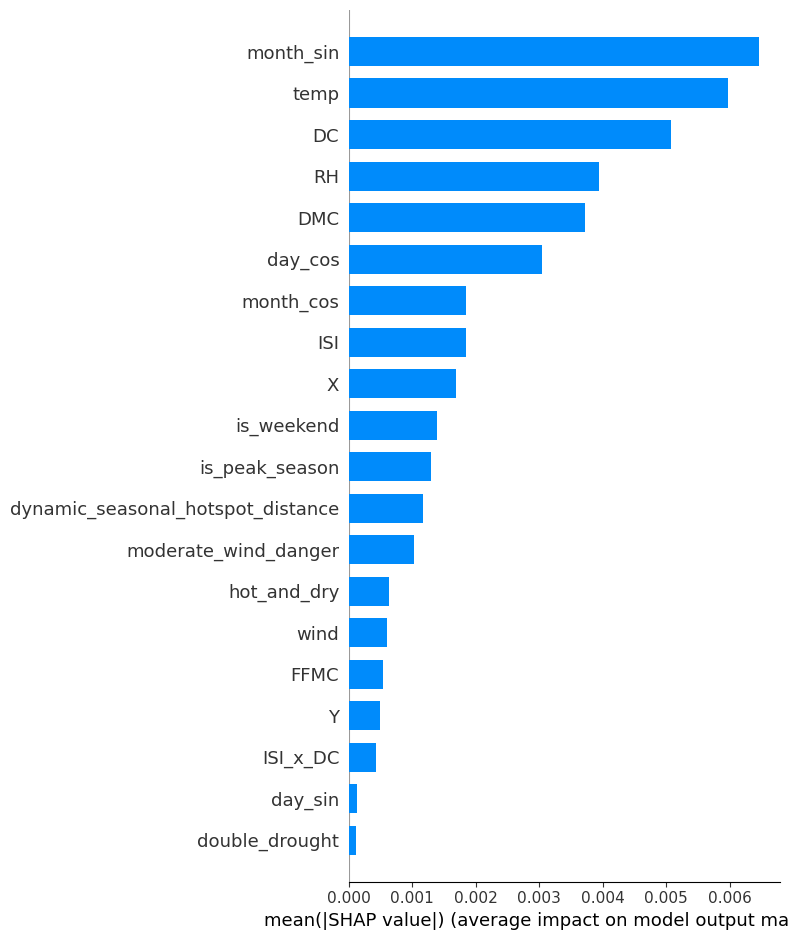


-> GRAFİK 2: Arı Kovanı Grafiği


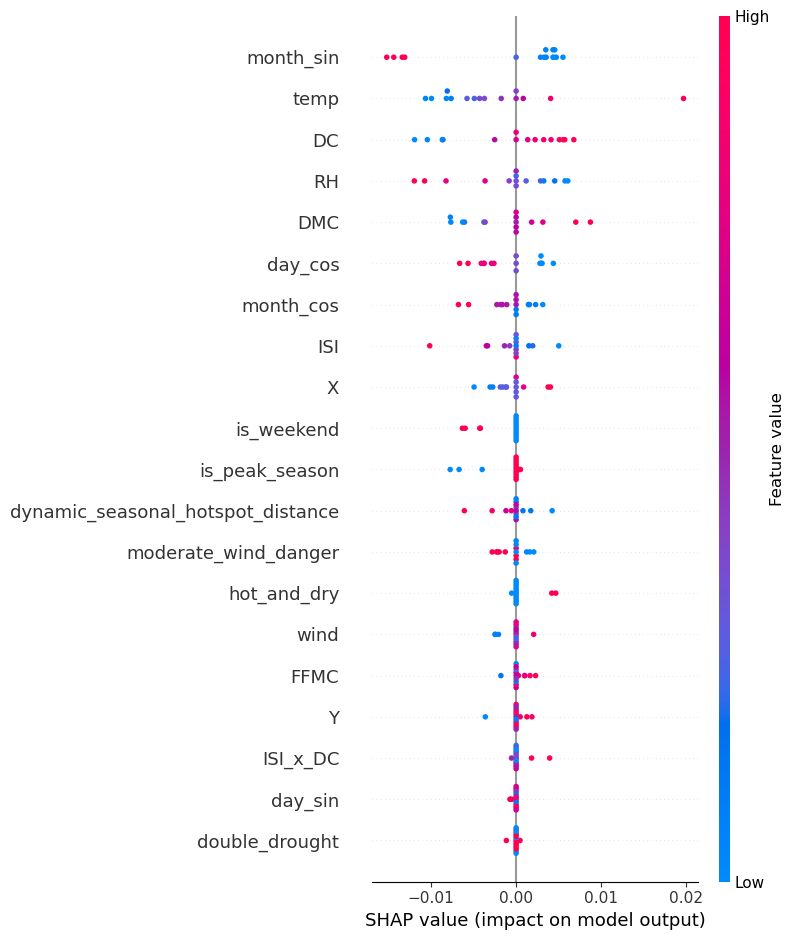

In [27]:
import shap
import matplotlib.pyplot as plt

background = shap.kmeans(X_train, 10)

def predict_fn(X):
    X_df = pd.DataFrame(X, columns=X_train.columns)
    return champion_node.predict(X_df)

explainer = shap.KernelExplainer(predict_fn, background)

X_test_shap = X_test.head(15)

print("-> SHAP Değerleri Hesaplanıyor ")
shap_values = explainer.shap_values(X_test_shap, nsamples=100)

shap_vals_to_plot = shap_values[0] if isinstance(shap_values, list) else shap_values

print("\n-> GRAFİK 1: Özellik Önem Sıralaması")
plt.figure()
shap.summary_plot(shap_vals_to_plot, X_test_shap, plot_type="bar")

print("\n-> GRAFİK 2: Arı Kovanı Grafiği")
plt.figure()
shap.summary_plot(shap_vals_to_plot, X_test_shap)